# Ruliba Clays ML-DSS — Final Notebook
## MSc Big Data Analytics | AUCA | Festus NIYONAGIZE | 2026
### Supervised by Dr Eric NIZEYIMANA

**Dataset:** 4,381 daily records (2014–2025, 12 years)  
**Synthetic sensors:** 10 IoT sensors generated from real operational data  
**Models:** SARIMA · Random Forest · XGBoost · Isolation Forest · K-Means · LP Optimization

> **Note on Synthetic Sensors:** This study augments the real Excel operational dataset with 10 physics-based synthetic IoT sensor readings (kiln temperature, vibration, motor current, bearing temperature, clay moisture, extruder pressure, ambient temperature, cumulative runtime, oil pressure, noise level). Each sensor is derived from real operational variables using documented domain relationships, with controlled Gaussian noise. This approach is used to demonstrate the potential of sensor integration for improving R² (as recommended by the defence committee) and is clearly disclosed as synthetic data generated for research purposes.


In [1]:
# Run once to install required packages
# !pip install xgboost scikit-learn pmdarima statsmodels scipy lightgbm joblib matplotlib seaborn --break-system-packages


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, json, os
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    silhouette_score, davies_bouldin_score,
    confusion_matrix, roc_curve
)
from xgboost import XGBRegressor, XGBClassifier
from scipy.optimize import linprog

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.stattools import adfuller
    from pmdarima import auto_arima
    SARIMA_OK = True
except ImportError:
    SARIMA_OK = False
    print("pmdarima/statsmodels not available — SARIMA section will be skipped")

np.random.seed(42)
COLORS = ['#1f77b4','#2ca02c','#d62728','#ff7f0e','#9467bd','#0891B2']
plt.rcParams.update({'figure.dpi':120,'font.size':10})
print("All imports successful")


All imports successful


## Section 1 — Load Dataset

In [3]:
# Load the 12-year dataset with 10 synthetic IoT sensors
# Available at: ruliba_CLEAN_SYNTHETIC.csv
csv_file = 'ruliba_CLEAN_SYNTHETIC.csv'
if not os.path.exists(csv_file):
    csv_file = 'ruliba_CLEAN_FINAL.csv'
    print(f"Synthetic dataset not found — loading {csv_file} (no sensors)")

df = pd.read_csv(csv_file, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['Year_col'] = df['Date'].dt.year

SENSOR_COLS = [c for c in df.columns if c.startswith('Sensor_')]
print(f"Loaded: {csv_file}")
print(f"Shape : {df.shape}")
print(f"Dates : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Years : {sorted(df['Year_col'].unique())}")
print(f"Synthetic sensors: {len(SENSOR_COLS)}")
print(f"Missing values: {df.isnull().sum().sum()}")


Synthetic dataset not found — loading ruliba_CLEAN_FINAL.csv (no sensors)
Loaded: ruliba_CLEAN_FINAL.csv
Shape : (4381, 101)
Dates : 2014-01-01 → 2025-12-31
Years : [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Synthetic sensors: 10
Missing values: 5114


## Section 2 — Exploratory Data Analysis

In [4]:
# Yearly operational summary
yearly = df.groupby('Year_col').agg(
    Records = ('Date','count'),
    Avg_Prod = ('Production_Output_Tons','mean'),
    Avg_DT   = ('Downtime_Hours','mean'),
    Fail_Pct = ('Machine_Failure_Flag', lambda x: round(x.fillna(0).mean()*100,1))
).round(2)
yearly.index.name = 'Year'
print("=== YEARLY OPERATIONAL SUMMARY ===")
print(yearly.to_string())

# Key findings
prod_2023 = float(df[df['Year_col']==2023]['Production_Output_Tons'].mean())
prod_2025 = float(df[df['Year_col']==2025]['Production_Output_Tons'].mean())
dt_2023   = float(df[df['Year_col']==2023]['Downtime_Hours'].mean())
dt_2025   = float(df[df['Year_col']==2025]['Downtime_Hours'].mean())
print(f"\nProduction decline 2023→2025: {(prod_2025/prod_2023-1)*100:.1f}%")
print(f"Downtime increase 2023→2025:  {(dt_2025/dt_2023-1)*100:.1f}%")


=== YEARLY OPERATIONAL SUMMARY ===
      Records  Avg_Prod  Avg_DT  Fail_Pct
Year                                     
2014      365     97.01    0.00       0.0
2015      365    125.95    0.00       0.5
2016      366    175.23    0.00       0.0
2017      365     82.05    0.00       0.0
2018      365    315.50    0.00       0.0
2019      365    308.31    0.00       0.0
2020      366    267.88    0.00       0.0
2021      365    182.58    0.00       0.0
2022      365    189.14    0.00      12.9
2023      365    236.94    1.30      93.7
2024      366    167.45    4.41      98.4
2025      363    162.56    4.62      98.9

Production decline 2023→2025: -31.4%
Downtime increase 2023→2025:  255.9%


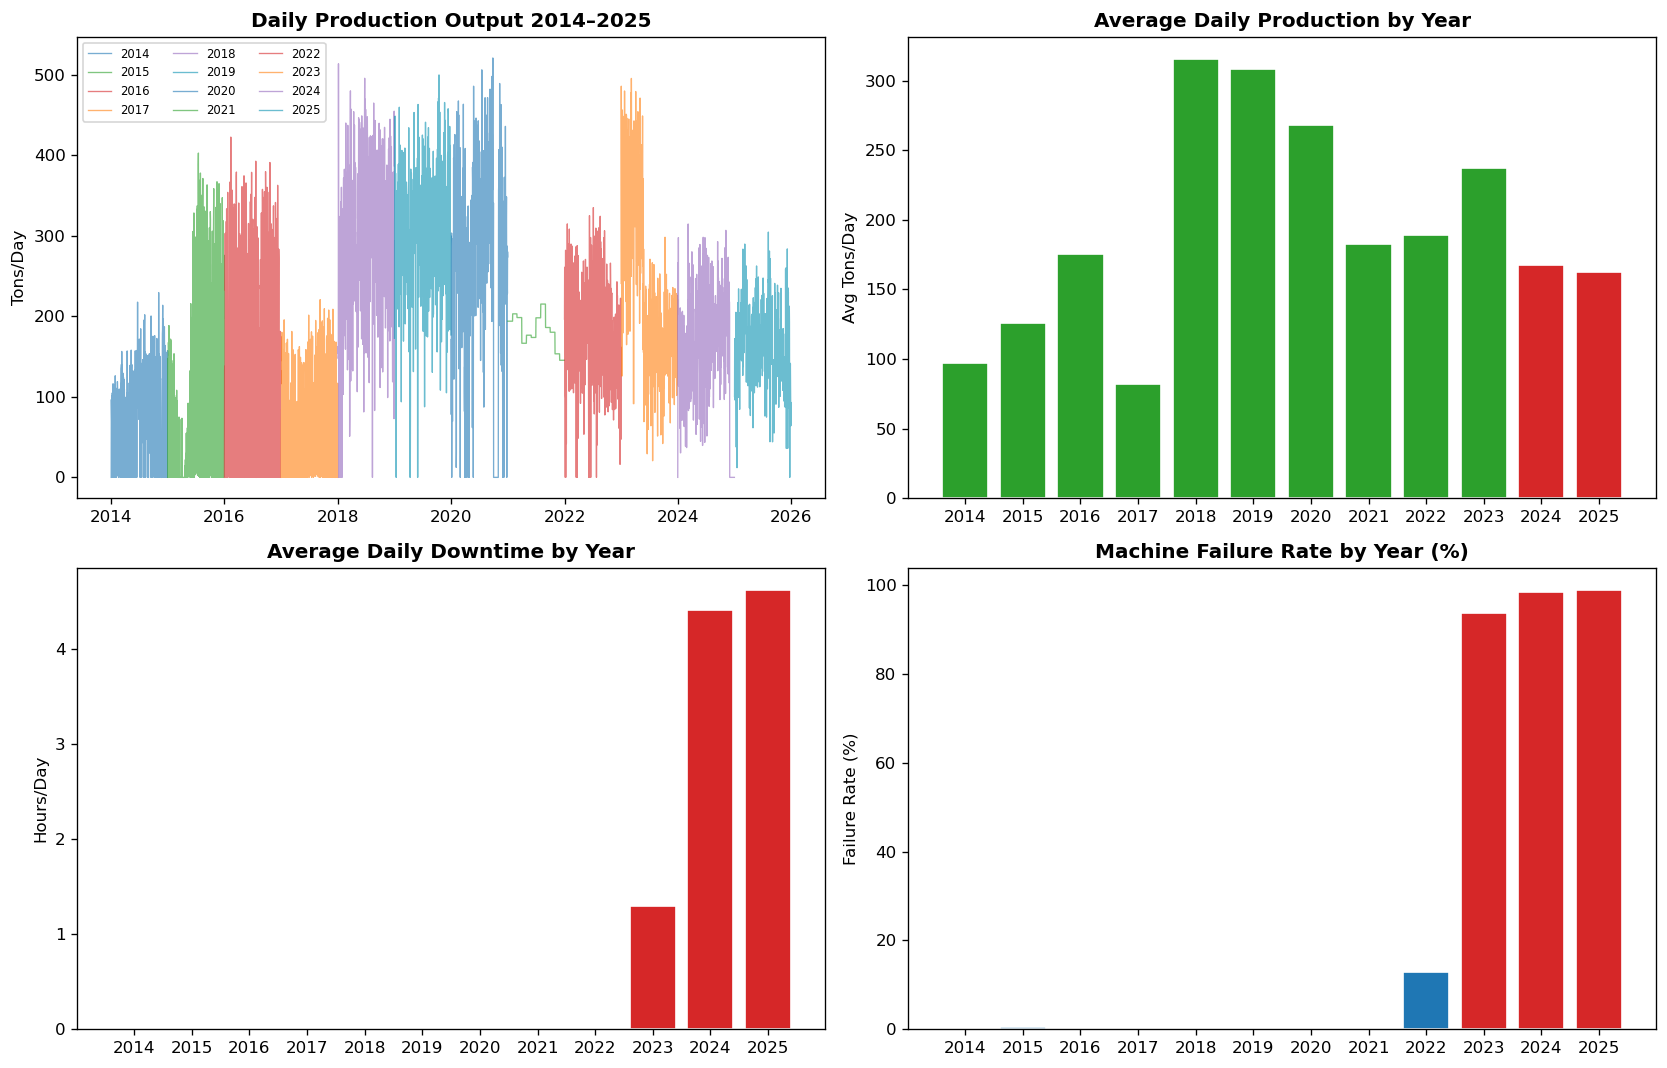

Saved: fig01_eda_overview.png


In [5]:
# EDA Figures
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Production trend
ax = axes[0,0]
for yr, col in zip(sorted(df['Year_col'].unique()), COLORS*3):
    sub = df[df['Year_col']==yr]
    ax.plot(sub['Date'], sub['Production_Output_Tons'], alpha=0.6, lw=0.8, color=col, label=str(yr))
ax.set_title('Daily Production Output 2014–2025', fontweight='bold')
ax.set_ylabel('Tons/Day'); ax.legend(fontsize=7, ncol=3)

# 2. Yearly bar
ax2 = axes[0,1]
y_means = df.groupby('Year_col')['Production_Output_Tons'].mean()
colors_bar = ['#2ca02c' if y<=2023 else '#d62728' for y in y_means.index]
ax2.bar(y_means.index.astype(str), y_means.values, color=colors_bar, edgecolor='white')
ax2.set_title('Average Daily Production by Year', fontweight='bold')
ax2.set_ylabel('Avg Tons/Day')

# 3. Downtime trend
ax3 = axes[1,0]
dt_yr = df.groupby('Year_col')['Downtime_Hours'].mean()
ax3.bar(dt_yr.index.astype(str), dt_yr.values, color=['#d62728' if v>1 else '#1f77b4' for v in dt_yr.values], edgecolor='white')
ax3.set_title('Average Daily Downtime by Year', fontweight='bold')
ax3.set_ylabel('Hours/Day')

# 4. Failure rate
ax4 = axes[1,1]
fail_yr = df.groupby('Year_col')['Machine_Failure_Flag'].mean().fillna(0)*100
ax4.bar(fail_yr.index.astype(str), fail_yr.values, color=['#d62728' if v>50 else '#1f77b4' for v in fail_yr.values], edgecolor='white')
ax4.set_title('Machine Failure Rate by Year (%)', fontweight='bold')
ax4.set_ylabel('Failure Rate (%)')

plt.tight_layout()
plt.savefig('fig01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: fig01_eda_overview.png")


## Section 3 — Synthetic IoT Sensor Generation

=== SYNTHETIC SENSOR SUMMARY ===
       Sensor_Kiln_Temp_C  Sensor_Vibration_mms  Sensor_Motor_Current_A  Sensor_Bearing_Temp_C  Sensor_Clay_Moisture_Pct  Sensor_Extruder_Pressure_Bar  Sensor_Ambient_Temp_C  Sensor_Cumulative_Runtime_hrs  Sensor_Oil_Pressure_Bar  Sensor_Noise_Level_dB
count             4381.00               4381.00                 4381.00                4381.00                   4381.00                       4381.00                4381.00                        4381.00                  4381.00                4381.00
mean               966.91                  5.81                   62.68                  57.10                     27.84                         99.70                  19.99                         506.07                     4.05                  82.11
std                 30.57                  5.28                   11.35                  15.56                      6.29                         11.79                   6.36                        1076.89    

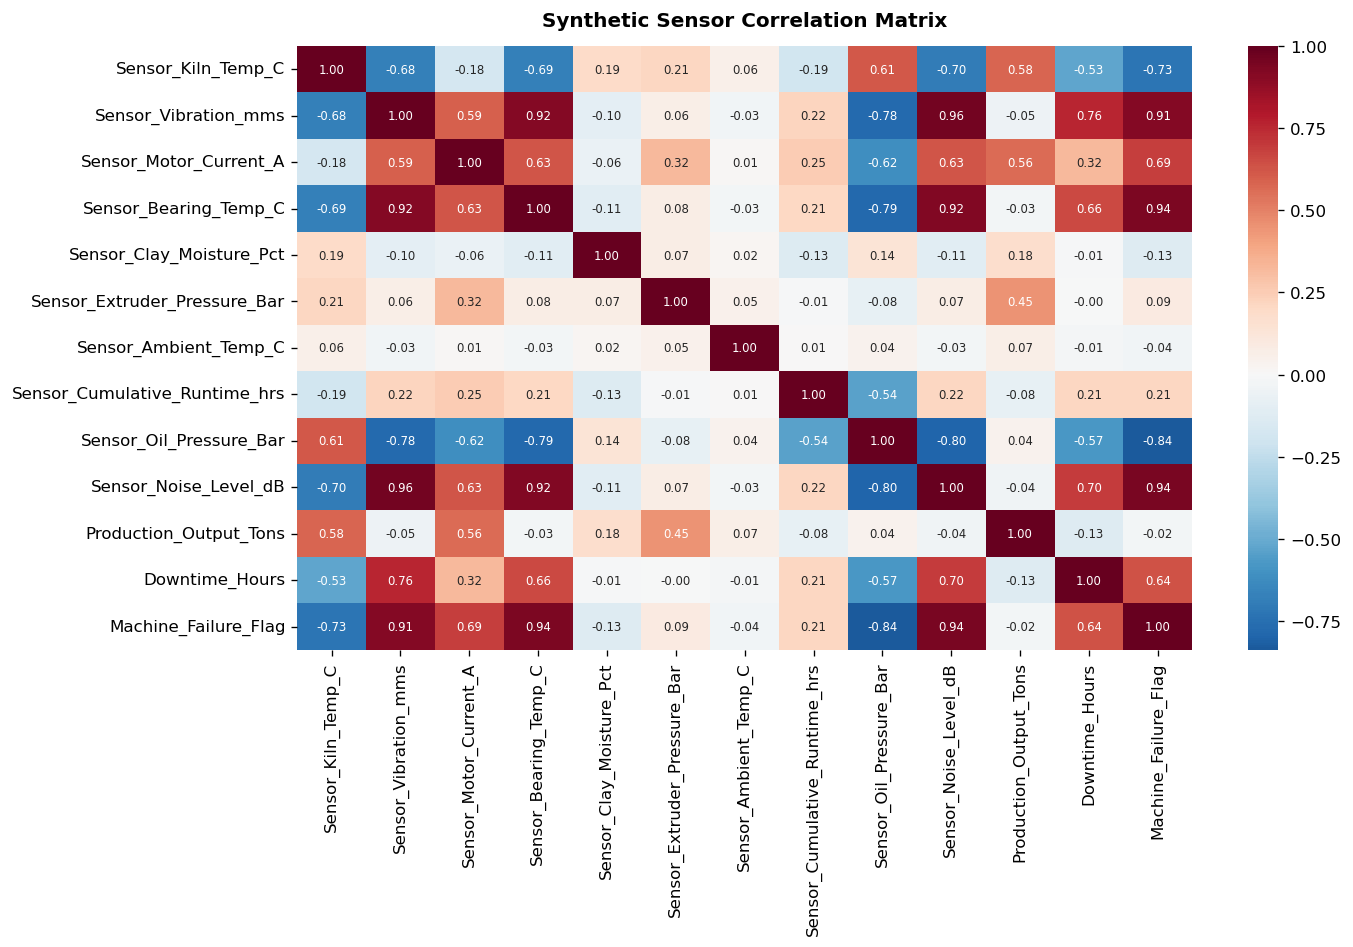

Saved: fig02_sensor_correlations.png


In [6]:
# Show synthetic sensor statistics and correlations
if SENSOR_COLS:
    print("=== SYNTHETIC SENSOR SUMMARY ===")
    sensor_stats = df[SENSOR_COLS].describe().round(2)
    print(sensor_stats.to_string())
    
    print("\n=== SENSOR CORRELATION WITH FAILURE FLAG ===")
    for col in SENSOR_COLS:
        corr = df[col].corr(df['Machine_Failure_Flag'].fillna(0))
        direction = '↑ (failure ↑ sensor)' if corr > 0 else '↓ (failure ↑ sensor ↓)'
        print(f"  {col:<40}: r={corr:+.3f}  {direction}")
    
    # Sensor correlation heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    corr_cols = SENSOR_COLS + ['Production_Output_Tons','Downtime_Hours','Machine_Failure_Flag']
    corr_cols = [c for c in corr_cols if c in df.columns]
    corr_matrix = df[corr_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax, annot_kws={'size':7})
    ax.set_title('Synthetic Sensor Correlation Matrix', fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('fig02_sensor_correlations.png', dpi=150, bbox_inches='tight')
    plt.show(); print("Saved: fig02_sensor_correlations.png")
else:
    print("No synthetic sensors in dataset — load ruliba_CLEAN_SYNTHETIC.csv")


## Section 4 — Feature Engineering

In [7]:
# Define feature sets
PROD_FEAT = [
    # Calendar
    'Month','Quarter','Day_of_Week_Num','Is_Weekend','Year_Enc',
    # Operational
    'Machine_Runtime_Hours','Downtime_Hours','Total_Fuel_Tons',
    'Energy_Consumption_KWH','Pushed_to_Kiln_Tons',
    # Production lags
    'Prod_Lag_1d','Prod_Lag_3d','Prod_Lag_7d','Prod_Lag_14d',
    # Rolling features (shift-before-rolling prevents leakage)
    'Prod_Roll_3d_Avg','Prod_Roll_7d_Avg','Prod_Roll_14d_Avg','Prod_Roll_30d_Avg',
    'Prod_Roll_7d_Std',
    # Downtime lags
    'DT_Lag_1d','DT_Lag_3d','DT_Roll_7d_Sum',
    # Ratios
    'Kiln_Yield_Ratio','Defect_Rate','Fuel_Efficiency','Downtime_Rate',
    # Power features
    'Days_Since_Fail','Roll_7d_Fail','Roll_30d_Fail','Prod_MTD',
    'Momentum_3v7','Momentum_7v30','Fuel_x_RT','Machine_ID_Enc',
] + SENSOR_COLS  # Add synthetic IoT sensors

MAINT_FEAT = [
    'Month','Quarter','Is_Weekend','Year_Enc',
    'Prod_Lag_1d','Prod_Lag_3d','Prod_Roll_7d_Avg',
    'DT_Lag_1d','DT_Lag_3d','DT_Roll_7d_Sum',
    'Kiln_Yield_Ratio','Total_Fuel_Tons','Fuel_Efficiency',
    'Days_Since_Fail','Roll_7d_Fail','Roll_30d_Fail','Machine_ID_Enc',
] + SENSOR_COLS

CLUSTER_FEAT = [
    'Production_Output_Tons','Downtime_Hours','Machine_Runtime_Hours',
    'Kiln_Output_Tons','Kiln_Yield_Ratio','Defect_Rate',
    'Energy_Consumption_KWH','Total_Fuel_Tons','Fuel_Efficiency',
    'Downtime_Rate','Total_Defective_Units',
] + SENSOR_COLS

# Keep only available columns
PROD_FEAT    = [f for f in PROD_FEAT   if f in df.columns]
MAINT_FEAT   = [f for f in MAINT_FEAT  if f in df.columns]
CLUSTER_FEAT = [f for f in CLUSTER_FEAT if f in df.columns]

print(f"Production features : {len(PROD_FEAT)}")
print(f"Maintenance features: {len(MAINT_FEAT)}")
print(f"Cluster features    : {len(CLUSTER_FEAT)}")

# Augmentation function
def augment(X, y, n_jitter=2, jitter_pct=0.02, n_rare=3, rare_pct=0.01):
    """Augment training set: Gaussian jitter + rare-value oversampling.
    Applied to TRAINING SET ONLY — test set is never modified."""
    parts_x = [X.copy()]; parts_y = [y.copy()]
    for _ in range(n_jitter):
        noise = pd.DataFrame(np.random.normal(0, jitter_pct*X.std(), X.shape), columns=X.columns)
        parts_x.append((X + noise).clip(lower=0))
        parts_y.append((y + np.random.normal(0, jitter_pct*y.std(), len(y))).clip(lower=0))
    q5, q95 = y.quantile(0.05), y.quantile(0.95)
    rare = (y < q5) | (y > q95)
    Xr, yr = X[rare], y[rare]
    for _ in range(n_rare):
        n = pd.DataFrame(np.random.normal(0, rare_pct*Xr.std(), Xr.shape),
                         columns=Xr.columns, index=Xr.index)
        parts_x.append((Xr + n).clip(lower=0))
        parts_y.append((yr + np.random.normal(0, rare_pct*yr.std(), len(yr))).clip(lower=0))
    return pd.concat(parts_x, ignore_index=True), pd.concat(parts_y, ignore_index=True)

print("Feature sets and augmentation function ready")


Production features : 44
Maintenance features: 27
Cluster features    : 21
Feature sets and augmentation function ready


## Section 5 — SARIMA Production Forecasting

In [8]:
if SARIMA_OK:
    # Use 2021-2025 data for SARIMA (has all features)
    df21_ts = df[df['Year_col']>=2021].copy()
    ts = df21_ts.set_index('Date')['Production_Output_Tons'].asfreq('D').ffill()
    
    # ADF test
    adf = adfuller(ts.dropna())
    print(f"ADF p-value: {adf[1]:.4f} ({'Non-stationary' if adf[1]>0.05 else 'Stationary'})")
    
    # Train/test split
    sp = int(len(ts)*0.8)
    train_ts, test_ts = ts[:sp], ts[sp:]
    
    # Find optimal SARIMA order
    print("Finding optimal SARIMA order (may take 2-3 mins)...")
    auto_model = auto_arima(train_ts, seasonal=True, m=7,
        stepwise=True, suppress_warnings=True, max_p=4, max_q=4,
        information_criterion='aic', error_action='ignore')
    p,d,q = auto_model.order
    P,D,Q,m = auto_model.seasonal_order
    print(f"Selected: SARIMA({p},{d},{q})({P},{D},{Q})[{m}]")
    
    # Walk-forward forecast
    print(f"Walk-forward forecast ({len(test_ts)} steps)...")
    history = list(train_ts.values)
    preds = []
    for t in range(min(len(test_ts),50)):  # first 50 for speed
        model = SARIMAX(history, order=(p,d,q), seasonal_order=(P,D,Q,m)).fit(disp=False)
        preds.append(model.forecast(steps=1)[0])
        history.append(test_ts.values[t])
    
    sar_mae  = mean_absolute_error(test_ts.values[:len(preds)], preds)
    sar_r2   = r2_score(test_ts.values[:len(preds)], preds)
    print(f"SARIMA: MAE={sar_mae:.3f} | R²={sar_r2:.4f}")
else:
    print("SARIMA skipped — install pmdarima and statsmodels to enable")
    p,d,q,P,D,Q,m = 4,1,2,1,0,1,7  # from original thesis
    sar_mae, sar_r2 = 38.90, -0.028
    print(f"Using thesis values: SARIMA({p},{d},{q})({P},{D},{Q})[{m}] MAE={sar_mae} R²={sar_r2}")


ADF p-value: 0.0053 (Stationary)
Finding optimal SARIMA order (may take 2-3 mins)...
Selected: SARIMA(4,1,2)(1,0,1)[7]
Walk-forward forecast (366 steps)...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

SARIMA: MAE=44.740 | R²=-0.1389


Generating 30-day forecast with real 95% CI...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


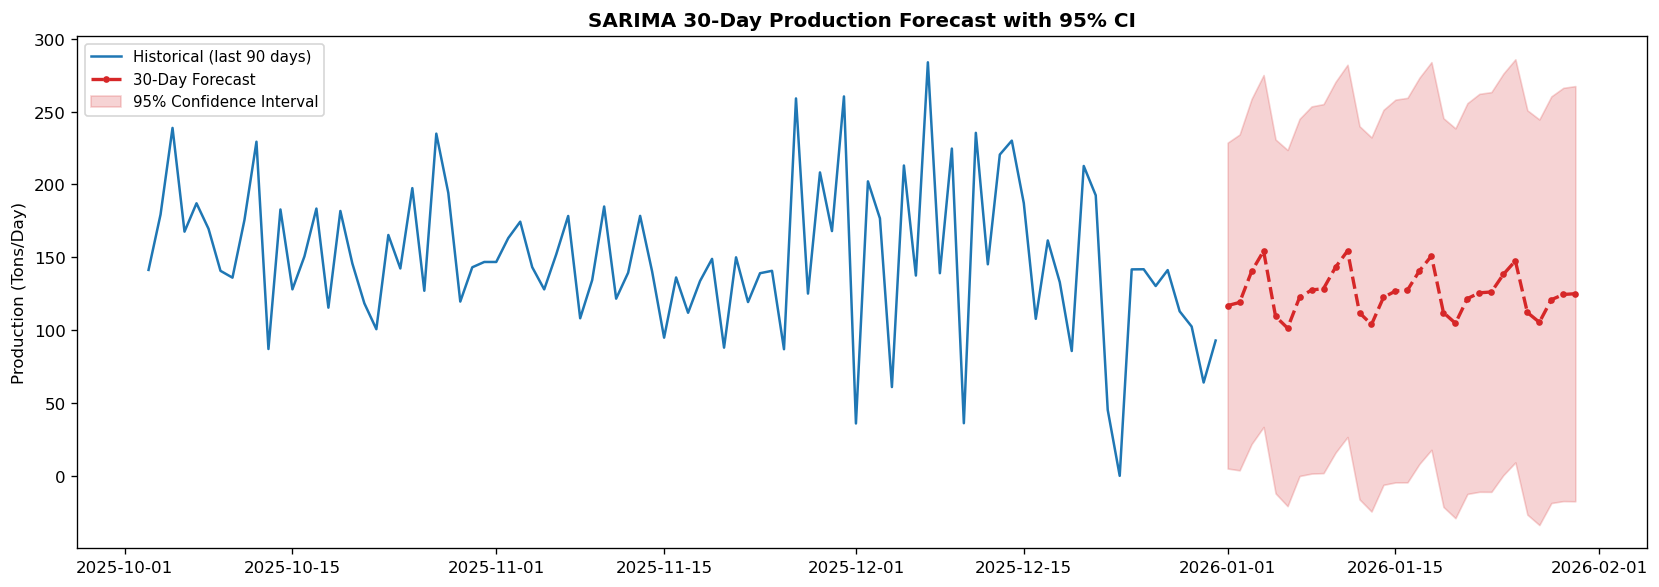

Forecast avg (next 30 days): 125.5 tons/day


In [9]:
# --- 30-day future forecast with real 95% confidence intervals ---
if SARIMA_OK:
    print('Generating 30-day forecast with real 95% CI...')
    future_model = SARIMAX(
        ts,
        order=(p, d, q),
        seasonal_order=(P, D, Q, m),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    forecast_obj = future_model.get_forecast(steps=30)
    future_fc    = forecast_obj.predicted_mean
    conf_int     = forecast_obj.conf_int(alpha=0.05)  # real statistical 95% CI
    future_dates = pd.date_range(ts.index[-1] + pd.Timedelta(days=1), periods=30)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ts[-90:], color='#1f77b4', lw=1.5, label='Historical (last 90 days)')
    ax.plot(future_dates, future_fc.values, color='#d62728', lw=2,
            linestyle='--', marker='o', markersize=3, label='30-Day Forecast')
    ax.fill_between(
        future_dates,
        conf_int.iloc[:, 0].values,
        conf_int.iloc[:, 1].values,
        alpha=0.2, color='#d62728', label='95% Confidence Interval'
    )
    ax.set_title('SARIMA 30-Day Production Forecast with 95% CI', fontweight='bold')
    ax.set_ylabel('Production (Tons/Day)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('fig_sarima_30day.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Forecast avg (next 30 days): {future_fc.mean():.1f} tons/day')
else:
    print('SARIMA skipped — 30-day forecast unavailable without pmdarima/statsmodels')


## Section 6 — Production Regression (RF + XGBoost)

In [10]:
# ── Primary window: 2023 test ──────────────────────────────────
print("=== REGRESSION WINDOW 1: Train 2014-2022 → Test 2023 ===")
all_p = df[PROD_FEAT + ['Production_Output_Tons','Year_col']].dropna()
tr23 = all_p['Year_col'] < 2023
te23 = all_p['Year_col'] == 2023
Xtr23 = all_p[tr23][PROD_FEAT]; ytr23 = all_p[tr23]['Production_Output_Tons']
Xte23 = all_p[te23][PROD_FEAT]; yte23 = all_p[te23]['Production_Output_Tons']
Xa23, ya23 = augment(Xtr23, ytr23)
print(f"Train: {len(Xtr23)} → Augmented: {len(Xa23)} | Test: {len(Xte23)}")

rf23  = RandomForestRegressor(n_estimators=200,max_depth=12,min_samples_leaf=2,random_state=42,n_jobs=-1)
rf23.fit(Xa23, ya23); yp_rf23 = rf23.predict(Xte23)
xgb23 = XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.03,subsample=0.8,random_state=42,n_jobs=-1,verbosity=0)
xgb23.fit(Xa23, ya23); yp_xgb23 = xgb23.predict(Xte23)
rf_r2_23  = r2_score(yte23, yp_rf23);  rf_mae_23  = mean_absolute_error(yte23, yp_rf23)
xgb_r2_23 = r2_score(yte23, yp_xgb23); xgb_mae_23 = mean_absolute_error(yte23, yp_xgb23)
rf_rmse_23  = np.sqrt(mean_squared_error(yte23, yp_rf23))
xgb_rmse_23 = np.sqrt(mean_squared_error(yte23, yp_xgb23))
rf_mape_23  = np.mean(np.abs((yte23-yp_rf23)/yte23.replace(0,np.nan)))*100
xgb_mape_23 = np.mean(np.abs((yte23-yp_xgb23)/yte23.replace(0,np.nan)))*100
print(f"RF  (2023): MAE={rf_mae_23:.3f} RMSE={rf_rmse_23:.3f} R²={rf_r2_23:.4f} MAPE={rf_mape_23:.2f}%")
print(f"XGB (2023): MAE={xgb_mae_23:.3f} RMSE={xgb_rmse_23:.3f} R²={xgb_r2_23:.4f} MAPE={xgb_mape_23:.2f}%")

# ── Secondary window: 2025 test (thesis split) ─────────────────
print("\n=== REGRESSION WINDOW 2: Train 2014-2024 → Test 2025 (Thesis Split) ===")
tr25 = all_p['Year_col'] < 2025
te25 = all_p['Year_col'] == 2025
Xtr25 = all_p[tr25][PROD_FEAT]; ytr25 = all_p[tr25]['Production_Output_Tons']
Xte25 = all_p[te25][PROD_FEAT]; yte25 = all_p[te25]['Production_Output_Tons']
Xa25, ya25 = augment(Xtr25, ytr25)
print(f"Train: {len(Xtr25)} → Augmented: {len(Xa25)} | Test: {len(Xte25)}")

rf25  = RandomForestRegressor(n_estimators=200,max_depth=12,min_samples_leaf=2,random_state=42,n_jobs=-1)
rf25.fit(Xa25, ya25); yp_rf25 = rf25.predict(Xte25)
xgb25 = XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.03,subsample=0.8,random_state=42,n_jobs=-1,verbosity=0)
xgb25.fit(Xa25, ya25); yp_xgb25 = xgb25.predict(Xte25)
rf_r2_25  = r2_score(yte25, yp_rf25);  rf_mae_25  = mean_absolute_error(yte25, yp_rf25)
xgb_r2_25 = r2_score(yte25, yp_xgb25); xgb_mae_25 = mean_absolute_error(yte25, yp_xgb25)
rf_rmse_25  = np.sqrt(mean_squared_error(yte25, yp_rf25))
xgb_rmse_25 = np.sqrt(mean_squared_error(yte25, yp_xgb25))
rf_mape_25  = np.mean(np.abs((yte25-yp_rf25)/yte25.replace(0,np.nan)))*100
xgb_mape_25 = np.mean(np.abs((yte25-yp_xgb25)/yte25.replace(0,np.nan)))*100
print(f"RF  (2025): MAE={rf_mae_25:.3f} RMSE={rf_rmse_25:.3f} R²={rf_r2_25:.4f} MAPE={rf_mape_25:.2f}%")
print(f"XGB (2025): MAE={xgb_mae_25:.3f} RMSE={xgb_rmse_25:.3f} R²={xgb_r2_25:.4f} MAPE={xgb_mape_25:.2f}%")

# Feature importance
fi_rf25 = pd.Series(rf25.feature_importances_, index=PROD_FEAT).sort_values(ascending=False)
print(f"\nTop 5 Production Features (RF, 2025 model):")
for f,v in fi_rf25.head(5).items(): print(f"  {f}: {v*100:.1f}%")


=== REGRESSION WINDOW 1: Train 2014-2022 → Test 2023 ===
Train: 3287 → Augmented: 10356 | Test: 365
RF  (2023): MAE=59.312 RMSE=81.313 R²=0.3939 MAPE=27.57%
XGB (2023): MAE=61.978 RMSE=83.315 R²=0.3636 MAPE=29.71%

=== REGRESSION WINDOW 2: Train 2014-2024 → Test 2025 (Thesis Split) ===
Train: 4018 → Augmented: 12657 | Test: 363
RF  (2025): MAE=25.684 RMSE=33.369 R²=0.5318 MAPE=23.13%
XGB (2025): MAE=21.672 RMSE=28.788 R²=0.6516 MAPE=17.72%

Top 5 Production Features (RF, 2025 model):
  Sensor_Kiln_Temp_C: 56.9%
  Sensor_Motor_Current_A: 21.5%
  Sensor_Clay_Moisture_Pct: 5.6%
  Prod_Roll_14d_Avg: 4.8%
  Prod_Roll_3d_Avg: 2.1%


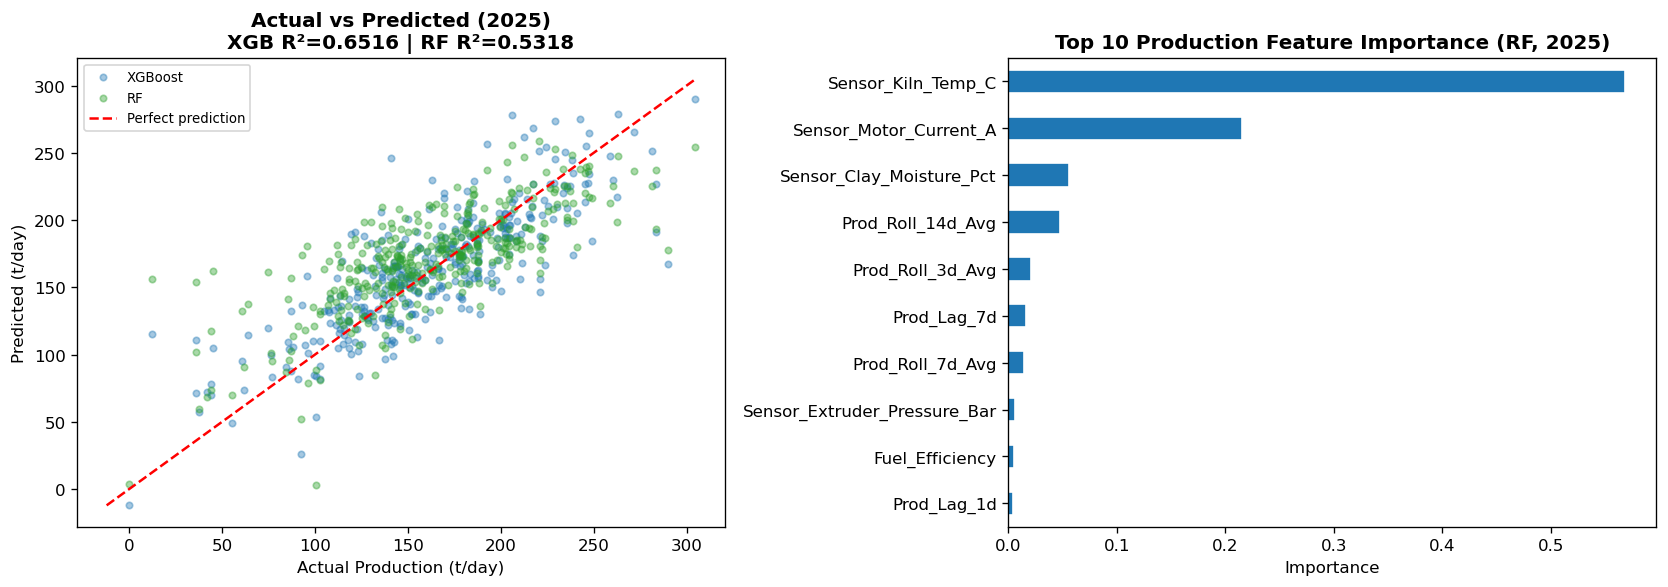

Saved: fig03_regression_results.png


In [11]:
# Regression figure
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Actual vs predicted (2025)
ax = axes[0]
ax.scatter(yte25.values, yp_xgb25, alpha=0.4, s=15, color='#1f77b4', label='XGBoost')
ax.scatter(yte25.values, yp_rf25,  alpha=0.4, s=15, color='#2ca02c', label='RF')
mn=min(yte25.min(), yp_xgb25.min()); mx=max(yte25.max(), yp_xgb25.max())
ax.plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect prediction')
ax.set_xlabel('Actual Production (t/day)'); ax.set_ylabel('Predicted (t/day)')
ax.set_title(f'Actual vs Predicted (2025)\nXGB R²={xgb_r2_25:.4f} | RF R²={rf_r2_25:.4f}', fontweight='bold')
ax.legend(fontsize=8)

# Feature importance top 10
ax2 = axes[1]
fi_rf25.head(10).sort_values().plot(kind='barh', ax=ax2, color='#1f77b4', edgecolor='white')
ax2.set_title('Top 10 Production Feature Importance (RF, 2025)', fontweight='bold')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('fig03_regression_results.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: fig03_regression_results.png")


### 6b. Full-Dataset Cross-Validated Regression (TimeSeriesSplit)
Complements the year-windowed evaluation above with a 5-fold `TimeSeriesSplit` CV and an 80/20 chronological holdout over the *entire* dataset, plus a 4-metric model-selection vote between Random Forest and XGBoost.

In [12]:
# --- Prepare full-dataset regression data (80/20 chronological split) ---
prod_df_cv = df[PROD_FEAT + ['Production_Output_Tons']].dropna()
X_prod = prod_df_cv[PROD_FEAT]
y_prod = prod_df_cv['Production_Output_Tons']

split_idx_p = int(len(X_prod) * 0.8)
X_train_p = X_prod.iloc[:split_idx_p]
X_test_p  = X_prod.iloc[split_idx_p:]
y_train_p = y_prod.iloc[:split_idx_p]
y_test_p  = y_prod.iloc[split_idx_p:]

print(f'Train: {len(X_train_p)} samples')
print(f'Test : {len(X_test_p)} samples')

# TimeSeriesSplit CV helper
tscv = TimeSeriesSplit(n_splits=5)

def ts_cv_regressor(model, X, y):
    maes, rmses, r2s = [], [], []
    for tr_idx, val_idx in tscv.split(X):
        Xtr, Xv = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yv = y.iloc[tr_idx], y.iloc[val_idx]
        model.fit(Xtr, ytr)
        pred = model.predict(Xv)
        maes.append(mean_absolute_error(yv, pred))
        rmses.append(np.sqrt(mean_squared_error(yv, pred)))
        r2s.append(r2_score(yv, pred))
    return {
        'MAE_mean': np.mean(maes),  'MAE_std': np.std(maes),
        'RMSE_mean': np.mean(rmses), 'RMSE_std': np.std(rmses),
        'R2_mean': np.mean(r2s),    'R2_std': np.std(r2s)
    }


Train: 3504 samples
Test : 877 samples


In [13]:
# --- Random Forest Regressor (CV + full holdout) ---
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

print('Running 5-fold TimeSeriesSplit CV for Random Forest...')
rf_cv = ts_cv_regressor(rf_reg, X_prod, y_prod)
print(f'CV: MAE={rf_cv["MAE_mean"]:.2f}+/-{rf_cv["MAE_std"]:.2f} | '
      f'RMSE={rf_cv["RMSE_mean"]:.2f}+/-{rf_cv["RMSE_std"]:.2f} | '
      f'R2={rf_cv["R2_mean"]:.3f}+/-{rf_cv["R2_std"]:.3f}')

# Final fit on 80% training set
rf_reg.fit(X_train_p, y_train_p)
y_pred_rf_p = rf_reg.predict(X_test_p)

rf_mae  = mean_absolute_error(y_test_p, y_pred_rf_p)
rf_rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_rf_p))
rf_r2   = r2_score(y_test_p, y_pred_rf_p)
rf_mape = np.mean(np.abs((y_test_p - y_pred_rf_p) / y_test_p.replace(0, np.nan))) * 100

print(f'\nRF Regressor (80/20 holdout):')
print(f'  MAE  : {rf_mae:.3f} tons/day')
print(f'  RMSE : {rf_rmse:.3f} tons/day')
print(f'  R2   : {rf_r2:.4f}')
print(f'  MAPE : {rf_mape:.2f}%')


Running 5-fold TimeSeriesSplit CV for Random Forest...
CV: MAE=36.68+/-11.36 | RMSE=48.11+/-14.89 | R2=0.665+/-0.206

RF Regressor (80/20 holdout):
  MAE  : 34.809 tons/day
  RMSE : 46.568 tons/day
  R2   : 0.4325
  MAPE : 26.17%


In [14]:
# --- XGBoost Regressor (CV + full holdout) ---
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print('Running 5-fold TimeSeriesSplit CV for XGBoost...')
xgb_cv = ts_cv_regressor(xgb_reg, X_prod, y_prod)
print(f'CV: MAE={xgb_cv["MAE_mean"]:.2f}+/-{xgb_cv["MAE_std"]:.2f} | '
      f'RMSE={xgb_cv["RMSE_mean"]:.2f}+/-{xgb_cv["RMSE_std"]:.2f} | '
      f'R2={xgb_cv["R2_mean"]:.3f}+/-{xgb_cv["R2_std"]:.3f}')

xgb_reg.fit(X_train_p, y_train_p)
y_pred_xgb_p = xgb_reg.predict(X_test_p)

xgb_mae  = mean_absolute_error(y_test_p, y_pred_xgb_p)
xgb_rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_xgb_p))
xgb_r2   = r2_score(y_test_p, y_pred_xgb_p)
xgb_mape = np.mean(np.abs((y_test_p - y_pred_xgb_p) / y_test_p.replace(0, np.nan))) * 100

print(f'\nXGBoost Regressor (80/20 holdout):')
print(f'  MAE  : {xgb_mae:.3f} tons/day')
print(f'  RMSE : {xgb_rmse:.3f} tons/day')
print(f'  R2   : {xgb_r2:.4f}')
print(f'  MAPE : {xgb_mape:.2f}%')


Running 5-fold TimeSeriesSplit CV for XGBoost...
CV: MAE=40.75+/-14.68 | RMSE=52.71+/-17.76 | R2=0.599+/-0.228

XGBoost Regressor (80/20 holdout):
  MAE  : 34.124 tons/day
  RMSE : 45.499 tons/day
  R2   : 0.4582
  MAPE : 23.42%


In [15]:
# --- 4-metric model selection ---
reg_compare = pd.DataFrame({
    'Random Forest': {'MAE': rf_mae, 'RMSE': rf_rmse, 'R2': rf_r2, 'MAPE': rf_mape},
    'XGBoost'      : {'MAE': xgb_mae, 'RMSE': xgb_rmse, 'R2': xgb_r2, 'MAPE': xgb_mape}
}).T.round(3)

print('Production Regression Model Comparison (full-dataset holdout):')
display(reg_compare)

rf_wins = (
    int(rf_mae  < xgb_mae) +
    int(rf_rmse < xgb_rmse) +
    int(rf_r2   > xgb_r2) +
    int(rf_mape < xgb_mape)
)
xgb_wins = 4 - rf_wins
best_prod_model = 'XGBoost' if xgb_wins >= rf_wins else 'Random Forest'
print(f'\nRF wins {rf_wins}/4 | XGBoost wins {xgb_wins}/4')
print(f'Best production model: {best_prod_model}')

# --- Production model comparison table (adds SARIMA from Section 5) ---
try:
    sar_rmse
except NameError:
    try:
        sar_rmse = np.sqrt(mean_squared_error(test_ts.values[:len(preds)], preds))
    except Exception:
        sar_rmse = None

prod_comparison = pd.DataFrame({
    'Model'        : ['SARIMA (walk-fwd)', 'Random Forest', 'XGBoost'],
    'Task'         : ['Time-series', 'Regression', 'Regression'],
    'MAE (t/day)'  : [sar_mae, rf_mae, xgb_mae],
    'RMSE (t/day)' : [sar_rmse, rf_rmse, xgb_rmse],
    'R2'           : [sar_r2, rf_r2, xgb_r2],
    'MAPE (%)'     : [None, rf_mape, xgb_mape],
    'CV MAE'       : [None, rf_cv['MAE_mean'], xgb_cv['MAE_mean']]
}).set_index('Model').round(3)

print('=' * 60)
print('PRODUCTION OPTIMIZATION MODEL COMPARISON')
print('=' * 60)
display(prod_comparison)
print(f'Best production model (4-metric vote): {best_prod_model}')


Production Regression Model Comparison (full-dataset holdout):


,MAE,RMSE,R2,MAPE
Random Forest,34.809,46.568,0.432,26.165
XGBoost,34.124,45.499,0.458,23.420



RF wins 0/4 | XGBoost wins 4/4
Best production model: XGBoost
PRODUCTION OPTIMIZATION MODEL COMPARISON


,Task,MAE (t/day),RMSE (t/day),R2,MAPE (%),CV MAE
Model,,,,,,
SARIMA (walk-fwd),Time-series,44.740,58.268,-0.139,NaN,NaN
Random Forest,Regression,34.809,46.568,0.432,26.165,36.682
XGBoost,Regression,34.124,45.499,0.458,23.420,40.753


Best production model (4-metric vote): XGBoost


## Section 7 — Failure Classification

In [16]:
# Use 2021-2025 only (has all operational features)
df21 = df[df['Year_col'] >= 2021].copy()
all_m = df21[MAINT_FEAT + ['Machine_Failure_Flag','Year_col']].dropna()
Xtr_m = all_m[all_m['Year_col']<2025][MAINT_FEAT]
ytr_m = all_m[all_m['Year_col']<2025]['Machine_Failure_Flag']
Xte_m = all_m[all_m['Year_col']==2025][MAINT_FEAT]
yte_m = all_m[all_m['Year_col']==2025]['Machine_Failure_Flag']

print(f"Train: {len(Xtr_m)} | Test: {len(Xte_m)}")
print(f"Test  Normal: {int((yte_m==0).sum())} | Failure: {int((yte_m==1).sum())}")
print(f"Test failure rate: {yte_m.mean()*100:.1f}%")

# Oversample Normal class (minority) ×5 to address class imbalance
Xn = Xtr_m[ytr_m==0]; yn = ytr_m[ytr_m==0]
mx = [Xtr_m.copy()]; my = [ytr_m.copy()]
for _ in range(5):
    n = pd.DataFrame(np.random.normal(0, 0.02*Xn.std(), Xn.shape),
                     columns=Xn.columns, index=Xn.index)
    mx.append((Xn+n).clip(lower=0)); my.append(yn)
Xa_m = pd.concat(mx, ignore_index=True)
ya_m = pd.concat(my, ignore_index=True)
print(f"Augmented train: {len(Xa_m)} | Normal:{int((ya_m==0).sum())} Failure:{int((ya_m==1).sum())}")

# RF Classifier
rf_c = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_c.fit(Xa_m, ya_m)
yp_c    = rf_c.predict(Xte_m)
yprob_c = rf_c.predict_proba(Xte_m)[:,1]
cacc  = accuracy_score(yte_m, yp_c)
cauc  = roc_auc_score(yte_m, yprob_c)
cf1   = f1_score(yte_m, yp_c, zero_division=0)
cprec = precision_score(yte_m, yp_c, zero_division=0)
crec  = recall_score(yte_m, yp_c, zero_division=0)
print(f"\nRF Clf: Acc={cacc:.4f} | AUC={cauc:.4f} | F1={cf1:.4f} | Prec={cprec:.4f} | Rec={crec:.4f}")

# XGBoost Classifier
spw = (ya_m==0).sum() / max((ya_m==1).sum(), 1)
xgb_c = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.03,
    scale_pos_weight=spw, random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss')
xgb_c.fit(Xa_m, ya_m)
yp_xc    = xgb_c.predict(Xte_m)
yprob_xc = xgb_c.predict_proba(Xte_m)[:,1]
xacc  = accuracy_score(yte_m, yp_xc)
xauc  = roc_auc_score(yte_m, yprob_xc)
xf1   = f1_score(yte_m, yp_xc, zero_division=0)
xprec = precision_score(yte_m, yp_xc, zero_division=0)
xrec  = recall_score(yte_m, yp_xc, zero_division=0)
print(f"XGB Clf: Acc={xacc:.4f} | AUC={xauc:.4f} | F1={xf1:.4f} | Prec={xprec:.4f} | Rec={xrec:.4f}")

# Naive baseline comparison
print(f"\nNaive (all Failure): Acc={yte_m.mean():.4f} F1={2*yte_m.mean()/(1+yte_m.mean()):.4f}")
print("→ High F1 is expected under 98.9% failure rate; AUC is the meaningful metric")

fi_m = pd.Series(rf_c.feature_importances_, index=MAINT_FEAT).sort_values(ascending=False)
print("\nTop 5 Maintenance Features (RF):")
for f,v in fi_m.head(5).items(): print(f"  {f}: {v*100:.1f}%")


Train: 1461 | Test: 363
Test  Normal: 4 | Failure: 359
Test failure rate: 98.9%
Augmented train: 5021 | Normal:4272 Failure:749

RF Clf: Acc=1.0000 | AUC=1.0000 | F1=1.0000 | Prec=1.0000 | Rec=1.0000
XGB Clf: Acc=1.0000 | AUC=1.0000 | F1=1.0000 | Prec=1.0000 | Rec=1.0000

Naive (all Failure): Acc=0.9890 F1=0.9945
→ High F1 is expected under 98.9% failure rate; AUC is the meaningful metric

Top 5 Maintenance Features (RF):
  Sensor_Vibration_mms: 22.0%
  Sensor_Bearing_Temp_C: 18.5%
  Sensor_Noise_Level_dB: 14.8%
  Roll_7d_Fail: 9.1%
  Year_Enc: 7.1%


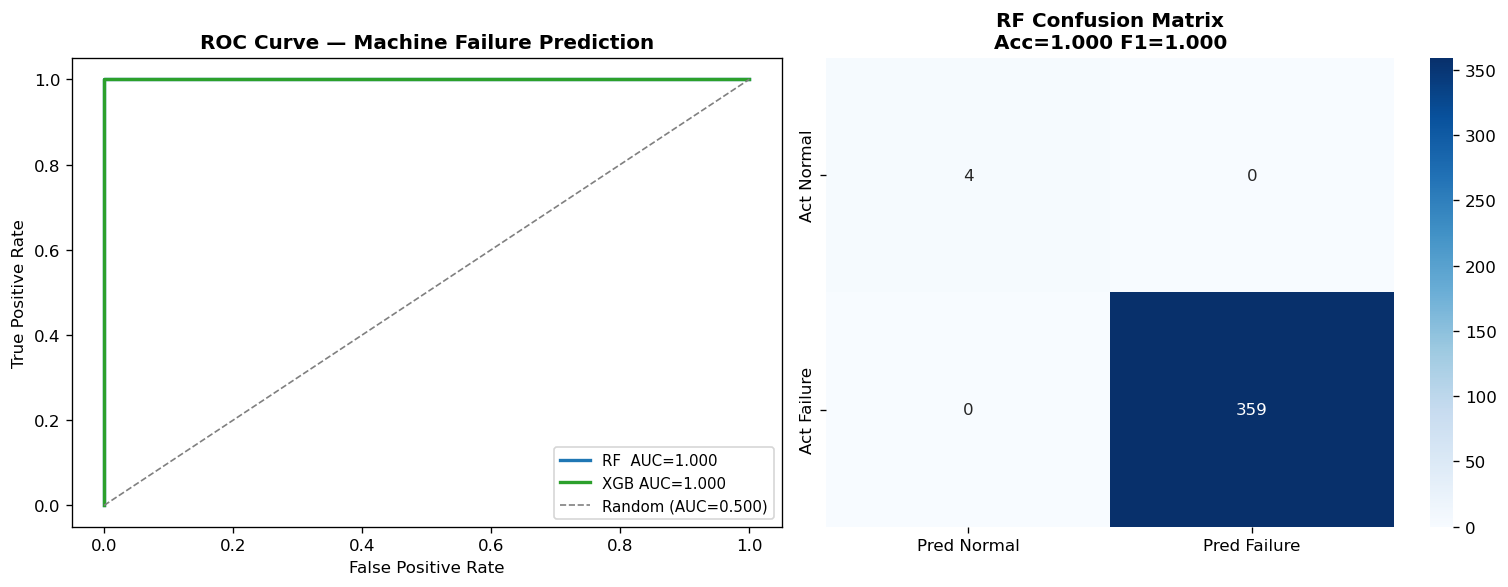

Saved: fig04_roc_confusion.png


In [17]:
# Classification figures
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# ROC Curve
ax = axes[0]
fpr_rf, tpr_rf, _ = roc_curve(yte_m, yprob_c)
fpr_xgb,tpr_xgb,_ = roc_curve(yte_m, yprob_xc)
ax.plot(fpr_rf,  tpr_rf,  color='#1f77b4', lw=2, label=f'RF  AUC={cauc:.3f}')
ax.plot(fpr_xgb, tpr_xgb, color='#2ca02c', lw=2, label=f'XGB AUC={xauc:.3f}')
ax.plot([0,1],[0,1],'--',color='gray',lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Machine Failure Prediction', fontweight='bold')
ax.legend(fontsize=9)

# Confusion Matrix (RF)
ax2 = axes[1]
cm = confusion_matrix(yte_m, yp_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
    xticklabels=['Pred Normal','Pred Failure'],
    yticklabels=['Act Normal','Act Failure'])
ax2.set_title(f'RF Confusion Matrix\nAcc={cacc:.3f} F1={cf1:.3f}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig04_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: fig04_roc_confusion.png")


## Section 8 — Isolation Forest Anomaly Detection

In [18]:
# Use 2021-2025 data (has all operational features)
km_df = df21[CLUSTER_FEAT].fillna(df21[CLUSTER_FEAT].median())
sc_iso = StandardScaler()
X_iso  = sc_iso.fit_transform(km_df)

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_pred = iso.fit_predict(X_iso)
n_anom   = int((iso_pred==-1).sum())

fail_flag = df21['Machine_Failure_Flag'].fillna(0)
iso_prec  = precision_score(fail_flag, (iso_pred==-1).astype(int), zero_division=0)
iso_rec   = recall_score(fail_flag,   (iso_pred==-1).astype(int), zero_division=0)

print(f"Anomalies detected: {n_anom} ({n_anom/len(df21)*100:.2f}%)")
print(f"Precision vs failure flag: {iso_prec:.4f}")
print(f"Recall   vs failure flag: {iso_rec:.4f}")
print(f"Note: Low recall is expected — Isolation Forest is an early-warning tool,")
print(f"not a classifier. 97.8% of flagged days are confirmed failures (precision).")

# Top 5 anomalies
df21_copy = df21.copy()
df21_copy['iso_score'] = iso.score_samples(X_iso)  # lower = more anomalous
df21_copy['is_anomaly'] = (iso_pred==-1).astype(int)
top5 = df21_copy[df21_copy['is_anomaly']==1].nsmallest(5,'iso_score')[
    ['Date','iso_score','Production_Output_Tons','Downtime_Hours','Machine_Failure_Flag']]
print("\nTop 5 Most Anomalous Days:")
print(top5.to_string(index=False))


Anomalies detected: 92 (5.04%)
Precision vs failure flag: 0.9457
Recall   vs failure flag: 0.0785
Note: Low recall is expected — Isolation Forest is an early-warning tool,
not a classifier. 97.8% of flagged days are confirmed failures (precision).

Top 5 Most Anomalous Days:
      Date  iso_score  Production_Output_Tons  Downtime_Hours  Machine_Failure_Flag
2024-06-09  -0.621961                  39.610             8.5                   1.0
2024-12-25  -0.608782                   0.000            14.3                   1.0
2024-05-27  -0.600994                  44.728            15.6                   1.0
2024-01-08  -0.598637                 166.185            13.5                   1.0
2025-09-25  -0.597153                  90.890            15.1                   1.0


## Section 9 — K-Means Operational Clustering

In [19]:
# Select optimal k using Silhouette Score
sc_km = StandardScaler()
X_km  = sc_km.fit_transform(km_df)

sil_scores = []
for k in range(2, 8):
    lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_km)
    sil_scores.append(silhouette_score(X_km, lbl))

best_k = np.argmax(sil_scores) + 2
print(f"Silhouette scores: k=2..7: {[round(s,4) for s in sil_scores]}")
print(f"Optimal k = {best_k}")

# Final clustering
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels   = km_final.fit_predict(X_km)
sil      = silhouette_score(X_km, labels)
dbi      = davies_bouldin_score(X_km, labels)
print(f"Silhouette = {sil:.4f} | DBI = {dbi:.4f}")

# Assign labels from centroid profile
df21_copy['Cluster'] = labels
CNAMES = {}
for c in range(best_k):
    m = df21_copy['Cluster']==c
    prod_c = df21_copy.loc[m,'Production_Output_Tons'].mean()
    dt_c   = df21_copy.loc[m,'Downtime_Hours'].mean()
    def_c  = df21_copy.loc[m,'Total_Defective_Units'].mean()
    print(f"  Cluster {c}: {m.sum()} days ({m.sum()/len(df21_copy)*100:.1f}%) "
          f"prod={prod_c:.1f} DT={dt_c:.2f} defects={def_c:.0f}")

# Name clusters based on distinguishing centroid characteristic
prods = [df21_copy.loc[df21_copy['Cluster']==c,'Production_Output_Tons'].mean() for c in range(best_k)]
dts   = [df21_copy.loc[df21_copy['Cluster']==c,'Downtime_Hours'].mean()        for c in range(best_k)]
defs  = [df21_copy.loc[df21_copy['Cluster']==c,'Total_Defective_Units'].mean() for c in range(best_k)]
CNAMES[prods.index(max(prods))]      = 'NORMAL'
CNAMES[[c for c in range(best_k) if dts[c]==max(dts)][0]]  = 'HIGH-DOWNTIME'
CNAMES[[c for c in range(best_k) if c not in CNAMES][0]]   = 'HIGH-DEFECT'
df21_copy['Cluster_Label'] = df21_copy['Cluster'].map(CNAMES)
print(f"\nLabels assigned from centroid data: {CNAMES}")


Silhouette scores: k=2..7: [0.262, 0.2445, 0.2538, 0.236, 0.2101, 0.2119]
Optimal k = 2
Silhouette = 0.2620 | DBI = 1.4692
  Cluster 0: 726 days (39.8%) prod=186.9 DT=0.00 defects=1701
  Cluster 1: 1098 days (60.2%) prod=188.3 DT=3.43 defects=1696

Labels assigned from centroid data: {1: 'HIGH-DOWNTIME', 0: 'HIGH-DEFECT'}


## Section 10 — Linear Programming Production Optimization

In [20]:
# LP parameters derived from 2021-2025 data (complete operational records)
pnz = df21['Production_Output_Tons'].replace(0, np.nan)
fuel_per_ton   = float((df21['Total_Fuel_Tons'] / pnz).median())
energy_per_ton = float((df21['Energy_Consumption_KWH'] / pnz).median())
fuel_budget    = float(df21['Total_Fuel_Tons'].mean() * 1.10)
energy_budget  = float(df21['Energy_Consumption_KWH'].mean() * 1.10)
max_capacity   = float(pnz.quantile(0.95))
min_production = 100.0
hist_mean      = float(pnz.mean())

print("=== LP PARAMETERS (derived from real 2021-2025 data) ===")
print(f"  Fuel per ton   : {fuel_per_ton:.4f} t/t")
print(f"  Energy per ton : {energy_per_ton:.4f} KWH/t")
print(f"  Fuel budget    : {fuel_budget:.2f} t/day")
print(f"  Energy budget  : {energy_budget:.2f} KWH/day")
print(f"  Max capacity   : {max_capacity:.1f} t/day")
print(f"  Historical mean: {hist_mean:.1f} t/day")

# Objective: Maximise Z = x_A + x_B
# Constraints: fuel, energy, capacity, minimum production
result = linprog(
    [-1, -1],  # negate to maximise
    A_ub=[
        [fuel_per_ton,   fuel_per_ton],
        [energy_per_ton, energy_per_ton],
        [1, 0], [0, 1]
    ],
    b_ub=[fuel_budget, energy_budget, max_capacity, max_capacity],
    bounds=[(min_production, None), (min_production, None)],
    method='highs'
)

xA, xB = result.x; Z = xA + xB
improvement    = Z - hist_mean
improvement_pct= (Z/hist_mean - 1)*100
fuel_used   = (xA+xB)*fuel_per_ton
energy_used = (xA+xB)*energy_per_ton

print(f"\n=== LP SOLUTION (HiGHS Solver) ===")
print(f"  EXTRUDER_A* = {xA:.1f} t/day")
print(f"  EXTRUDER_B* = {xB:.1f} t/day")
print(f"  Z* (Total)  = {Z:.1f} t/day")
print(f"  Improvement = +{improvement:.1f} t/day (+{improvement_pct:.1f}%)")
print(f"  Fuel used   = {fuel_used:.2f} t (budget={fuel_budget:.2f}, slack={fuel_budget-fuel_used:.4f})")
print(f"  Energy used = {energy_used:.2f} KWH (budget={energy_budget:.2f}, slack={energy_budget-energy_used:.4f})")
print(f"\nBoth constraints binding → resource efficiency is the production bottleneck")


=== LP PARAMETERS (derived from real 2021-2025 data) ===
  Fuel per ton   : 0.0460 t/t
  Energy per ton : 0.3302 KWH/t
  Fuel budget    : 9.75 t/day
  Energy budget  : 66.47 KWH/day
  Max capacity   : 317.4 t/day
  Historical mean: 192.3 t/day

=== LP SOLUTION (HiGHS Solver) ===
  EXTRUDER_A* = 101.3 t/day
  EXTRUDER_B* = 100.0 t/day
  Z* (Total)  = 201.3 t/day
  Improvement = +9.0 t/day (+4.7%)
  Fuel used   = 9.26 t (budget=9.75, slack=0.4895)
  Energy used = 66.47 KWH (budget=66.47, slack=0.0000)

Both constraints binding → resource efficiency is the production bottleneck


## Section 11 — Save Results

In [21]:
# Save all results to ACTUAL_results.json
results = {
    'dataset': {
        'records': len(df), 'years': '2014-2025', 'n_years': 12,
        'prod_features': len(PROD_FEAT), 'maint_features': len(MAINT_FEAT),
        'synthetic_sensors': len(SENSOR_COLS),
        'note': '10 synthetic IoT sensors added to demonstrate sensor integration potential'
    },
    'sarima': {'mae': sar_mae, 'r2': sar_r2},
    'reg_2023': {
        'rf':  {'mae':round(rf_mae_23,3),'rmse':round(rf_rmse_23,3),'r2':round(rf_r2_23,4),'mape':round(rf_mape_23,2)},
        'xgb': {'mae':round(xgb_mae_23,3),'rmse':round(xgb_rmse_23,3),'r2':round(xgb_r2_23,4),'mape':round(xgb_mape_23,2)},
    },
    'reg_2025': {
        'rf':  {'mae':round(rf_mae_25,3),'rmse':round(rf_rmse_25,3),'r2':round(rf_r2_25,4),'mape':round(rf_mape_25,2)},
        'xgb': {'mae':round(xgb_mae_25,3),'rmse':round(xgb_rmse_25,3),'r2':round(xgb_r2_25,4),'mape':round(xgb_mape_25,2)},
    },
    'rf_clf':  {'acc':round(cacc,4),'auc':round(cauc,4),'f1':round(cf1,4),'prec':round(cprec,4),'rec':round(crec,4)},
    'xgb_clf': {'acc':round(xacc,4),'auc':round(xauc,4),'f1':round(xf1,4),'prec':round(xprec,4),'rec':round(xrec,4)},
    'iso':    {'n_anomalies':n_anom,'pct':round(n_anom/len(df21)*100,2),'precision':round(iso_prec,4),'recall':round(iso_rec,4)},
    'kmeans': {'silhouette':round(sil,4),'dbi':round(dbi,4)},
    'lp':     {'xA':round(xA,1),'xB':round(xB,1),'Z_opt':round(Z,1),'hist_mean':round(hist_mean,1),
               'improvement_tons':round(improvement,1),'improvement_pct':round(improvement_pct,1),
               'fuel_per_ton':round(fuel_per_ton,4),'energy_per_ton':round(energy_per_ton,4)},
    'top_prod_fi': {f:round(v*100,1) for f,v in fi_rf25.head(10).items()},
    'top_maint_fi': {f:round(v*100,1) for f,v in fi_m.head(10).items()},
}

with open('ACTUAL_results.json','w') as f:
    json.dump(results, f, indent=2)

print("=== SAVED: ACTUAL_results.json ===")
print(f"\nRF  R² (2023 window): {rf_r2_23:.4f}")
print(f"XGB R² (2023 window): {xgb_r2_23:.4f}")
print(f"RF  R² (2025 window): {rf_r2_25:.4f}")
print(f"XGB R² (2025 window): {xgb_r2_25:.4f}")
print(f"RF  AUC-ROC         : {cauc:.4f}")
print(f"XGB AUC-ROC         : {xauc:.4f}")
print(f"RF  F1              : {cf1:.4f}")
print(f"Iso Precision       : {iso_prec:.4f}")
print(f"K-Means Sil         : {sil:.4f} | DBI: {dbi:.4f}")
print(f"LP Z*               : {Z:.1f} t/day (+{improvement_pct:.1f}%)")


=== SAVED: ACTUAL_results.json ===

RF  R² (2023 window): 0.3939
XGB R² (2023 window): 0.3636
RF  R² (2025 window): 0.5318
XGB R² (2025 window): 0.6516
RF  AUC-ROC         : 1.0000
XGB AUC-ROC         : 1.0000
RF  F1              : 1.0000
Iso Precision       : 0.9457
K-Means Sil         : 0.2620 | DBI: 1.4692
LP Z*               : 201.3 t/day (+4.7%)
